In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import itertools
import gametheory as gt
import csv

ruta_datos = "/Users/jose/Desktop/GameTheory_project/filtered_gene_bc_matrices/hg19/"

adata = sc.read_10x_mtx(ruta_datos, var_names='gene_symbols')

print(adata)

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'


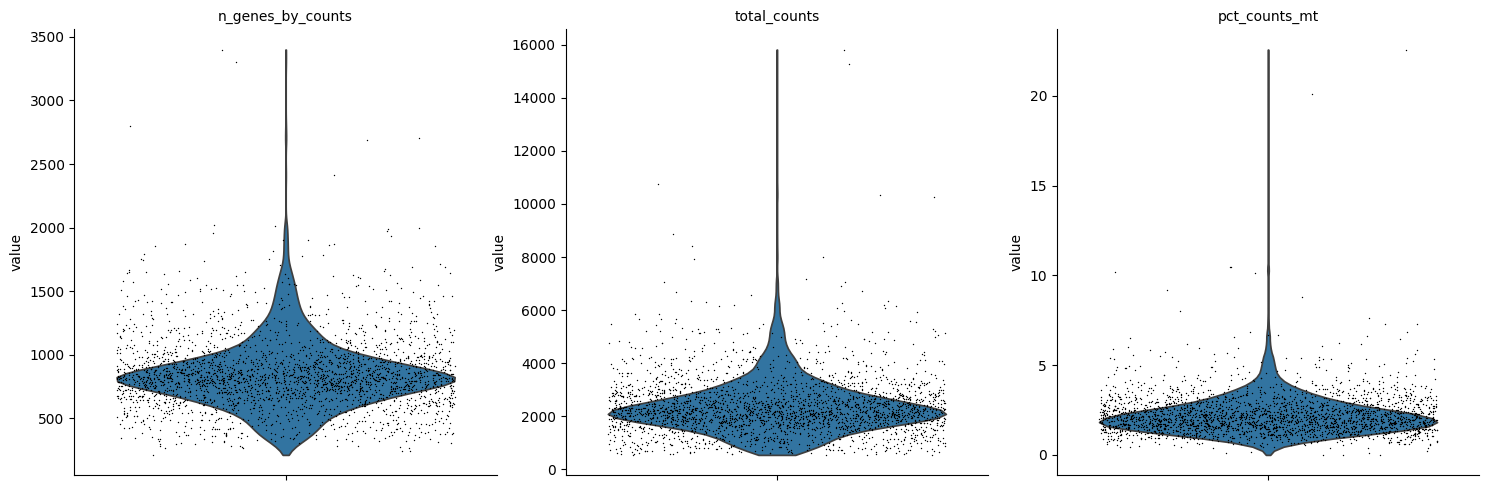

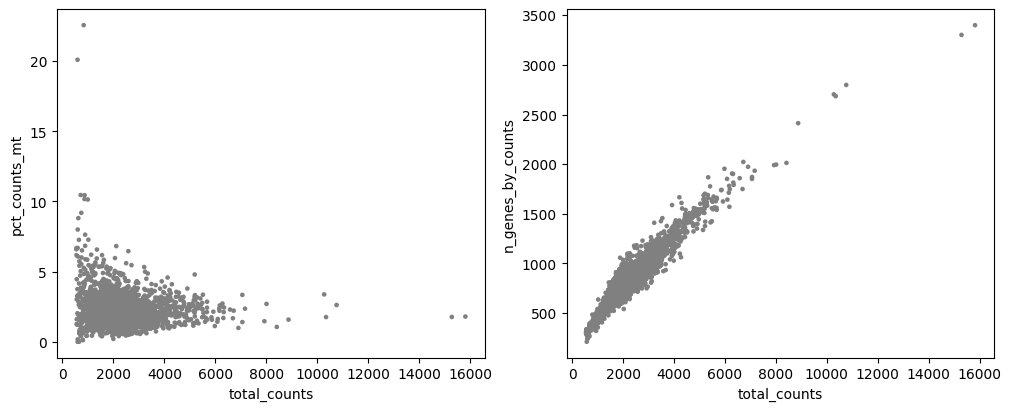

In [2]:
# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt", show=False, ax=axs[0])
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", show=False, ax=axs[1]);

adata = adata[
    (adata.obs.n_genes_by_counts < 2500)
    & (adata.obs.n_genes_by_counts > 200)
    & (adata.obs.pct_counts_mt < 5),
    :,
].copy()
adata.layers["counts"] = adata.X.copy()

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
    layers: 'counts'


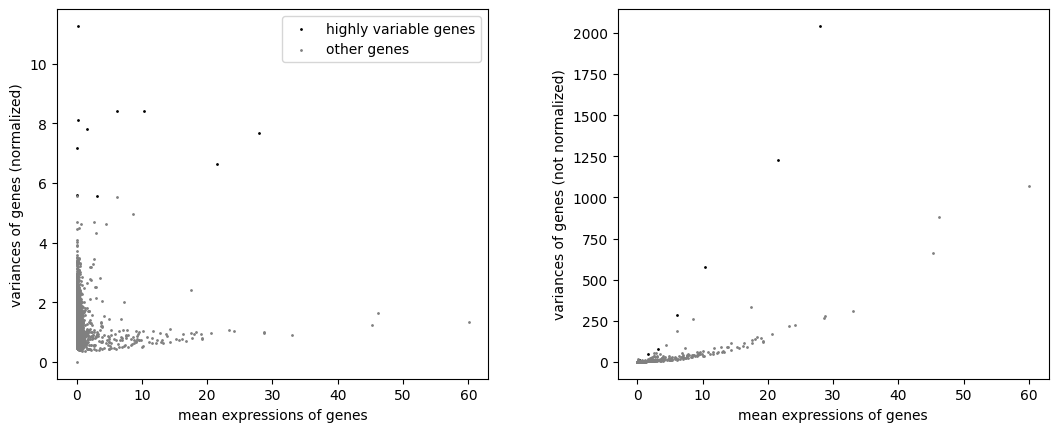

AL627309.1       False
AP006222.2       False
RP11-206L10.2    False
RP11-206L10.9    False
LINC00115        False
                 ...  
AC145212.1       False
AL592183.1       False
AL354822.1       False
PNRC2-1          False
SRSF10-1         False
Name: highly_variable, Length: 13714, dtype: bool
['S100A9', 'S100A8', 'GNLY', 'PF4', 'PPBP', 'GNG11', 'FTH1', 'LYZ', 'FTL', 'IGLL5']


In [3]:
sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)

print(adata)

sc.pp.highly_variable_genes(adata,layer="counts",n_top_genes=10,min_mean=0.0125,max_mean=3,min_disp=0.5,flavor="seurat_v3")

sc.pl.highly_variable_genes(adata)

print(adata.var['highly_variable'])

genes_mas_variables = adata.var[adata.var['highly_variable']]

indices_genes_mas_variables = np.where(adata.var['highly_variable'])[0]

#Guardar genes mas variables
genes_mas_variables.to_csv("/Users/jose/Desktop/GameTheory_project/genes_mas_variables.csv")
np.savetxt("/Users/jose/Desktop/GameTheory_project/indices_genes_mas_variables.csv", indices_genes_mas_variables, delimiter=",")

genes_mas_variables_array = np.array(genes_mas_variables)

nombres_genes_mas_variables = adata.var[adata.var['highly_variable']].index.tolist()

print(nombres_genes_mas_variables)

In [ ]:
combinaciones_todos_tamanos = []

for r in range(1, len(nombres_genes_mas_variables) + 1):
    combinaciones_todos_tamanos.extend(itertools.combinations(indices_genes_mas_variables, r))

#for combinacion in combinaciones_todos_tamanos:
#   print(combinacion)

#with open("/Users/jose/Desktop/GameTheory_project/combinaciones.csv", "w", newline="") as archivo_csv:
#    escritor = csv.writer(archivo_csv)
#    escritor.writerows(combinaciones_todos_tamanos)

print("Tamaño combinaciones de todos los tamaños:")
print(len(combinaciones_todos_tamanos))

# ESTRATEGIA HÍBRIDA:
# 1. Matriz RAW para calcular_CV_grupo_genes (que normaliza internamente)
matriz_raw = np.array(adata.layers["counts"].toarray()).T

# 2. Matriz normalizada para cálculos individuales de CV, varianza y media
matriz_norm = np.array(adata.X.toarray()).T

num_filas, num_columnas = matriz_raw.shape

print("NOTA: Estrategia híbrida implementada:")
print("      - matriz_raw: Para calcular_CV_grupo_genes (normaliza internamente)")
print("      - matriz_norm: Para cálculos individuales de CV, varianza y media")

# Para mantener compatibilidad, usamos matriz_raw como 'matriz' principal
matriz = matriz_raw

print(f"Número de filas (genes): {num_filas}")
print(f"Número de columnas (células): {num_columnas}")

ganancias = {}

# MÉTODO DE CÁLCULO: Elegir entre 'cv' (coeficiente de variación) o 'varianza'
metodo_calculo = 'varianza'  # Cambiar a 'varianza' si se desea usar varianza simple

print(f"Método de cálculo seleccionado: {metodo_calculo}")

for combinacion in combinaciones_todos_tamanos:
    
    ganancias[combinacion] = gt.calcular_valores_coaliciones(matriz_raw, np.array(combinacion), normalizar=True, metodo=metodo_calculo)

print("Ganancias de todas las coaliciones:")

i=0
gan = np.zeros(len(ganancias))

for combinacion, valor in ganancias.items():
    gan[i] = valor
    print(f"Combinación: {combinacion}, Valor: {valor}")
    i += 1
#np.savetxt("/Users/jose/Desktop/GameTheory_project/CoeficienteVariacionCoaliciones.csv", ganancias, delimiter=",",fmt="%.2f")


Tamaño combinaciones de todos los tamaños:
1023
NOTA: Estrategia híbrida implementada:
      - matriz_raw: Para calcular_CV_grupo_genes (normaliza internamente)
      - matriz_norm: Para cálculos individuales de CV, varianza y media
Número de filas (genes): 13714
Número de columnas (células): 2638
Método de cálculo seleccionado: varianza
Ganancias de todas las coaliciones:
Combinación: (np.int64(907),), Coeficiente de variación: 6.902175198861148
Combinación: (np.int64(909),), Coeficiente de variación: 5.349837518115336
Combinación: (np.int64(1803),), Coeficiente de variación: 3.1561456914874486
Combinación: (np.int64(3314),), Coeficiente de variación: 0.3363747812288271
Combinación: (np.int64(3315),), Coeficiente de variación: 0.5426406958379092
Combinación: (np.int64(5198),), Coeficiente de variación: 0.25583606920672913
Combinación: (np.int64(7754),), Coeficiente de variación: 2.739306137216343
Combinación: (np.int64(8681),), Coeficiente de variación: 7.498870890696915
Combinación: 

In [5]:
y = gt.valores_shapley(indices_genes_mas_variables, {frozenset(k): v for k, v in ganancias.items()})

print("Valores de Shapley:")

for jugador, valor_shap in y.items(): 
    print(f"Jugador: {jugador}, Valor Shapley: {valor_shap}")

Valores de Shapley:
Jugador: 907, Valor Shapley: 1.668494355865458
Jugador: 909, Valor Shapley: 1.197668528406416
Jugador: 1803, Valor Shapley: 0.5392252838957482
Jugador: 3314, Valor Shapley: 0.06470810919134534
Jugador: 3315, Valor Shapley: 0.11835184029203441
Jugador: 5198, Valor Shapley: 0.04440228686379163
Jugador: 7754, Valor Shapley: -1.4226693895401756
Jugador: 8681, Valor Shapley: 1.7247414713706866
Jugador: 12943, Valor Shapley: -0.8720849962471956
Jugador: 13274, Valor Shapley: 0.1119672867960897


In [6]:
# Calcular varianzas de los genes más variables
print("=== ANÁLISIS DE VARIANZAS DE GENES MÁS VARIABLES (DATOS NORMALIZADOS) ===\n")

# Obtener los datos de expresión de los genes más variables (normalizados)
matriz_genes_variables = matriz_norm[indices_genes_mas_variables, :]

# Calcular varianza para cada gen individual (usando datos normalizados)
varianzas_genes = np.var(matriz_genes_variables, axis=1)

# Crear un DataFrame con nombres de genes y sus varianzas
df_varianzas = pd.DataFrame({
    'gen': nombres_genes_mas_variables,
    'indice': indices_genes_mas_variables,
    'varianza': varianzas_genes
})

# Ordenar por varianza (de mayor a menor)
df_varianzas_ordenado = df_varianzas.sort_values('varianza', ascending=False)

print("Top 10 genes con mayor varianza:")
print(df_varianzas_ordenado.head(10))

print(f"\nEstadísticas de varianza:")
print(f"Varianza promedio: {np.mean(varianzas_genes):.4f}")
print(f"Varianza máxima: {np.max(varianzas_genes):.4f}")
print(f"Varianza mínima: {np.min(varianzas_genes):.4f}")
print(f"Desviación estándar de varianzas: {np.std(varianzas_genes):.4f}")

# Guardar resultados en CSV
df_varianzas_ordenado.to_csv("/Users/jose/Desktop/GameTheory_project/varianzas_genes_variables.csv", index=False)
print(f"\nResultados guardados en: varianzas_genes_variables.csv")

=== ANÁLISIS DE VARIANZAS DE GENES MÁS VARIABLES (DATOS NORMALIZADOS) ===

Top 10 genes con mayor varianza:
      gen  indice  varianza
7     LYZ    8681  3.602855
0  S100A9     907  3.316171
1  S100A8     909  2.570346
8     FTL   12943  1.672429
2    GNLY    1803  1.516380
6    FTH1    7754  1.316108
9   IGLL5   13274  0.329681
4    PPBP    3315  0.260713
3     PF4    3314  0.161612
5   GNG11    5198  0.122917

Estadísticas de varianza:
Varianza promedio: 1.4869
Varianza máxima: 3.6029
Varianza mínima: 0.1229
Desviación estándar de varianzas: 1.2458

Resultados guardados en: varianzas_genes_variables.csv


=== GRÁFICO: VALORES DE SHAPLEY VS VARIANZAS Y CV (DATOS NORMALIZADOS) ===



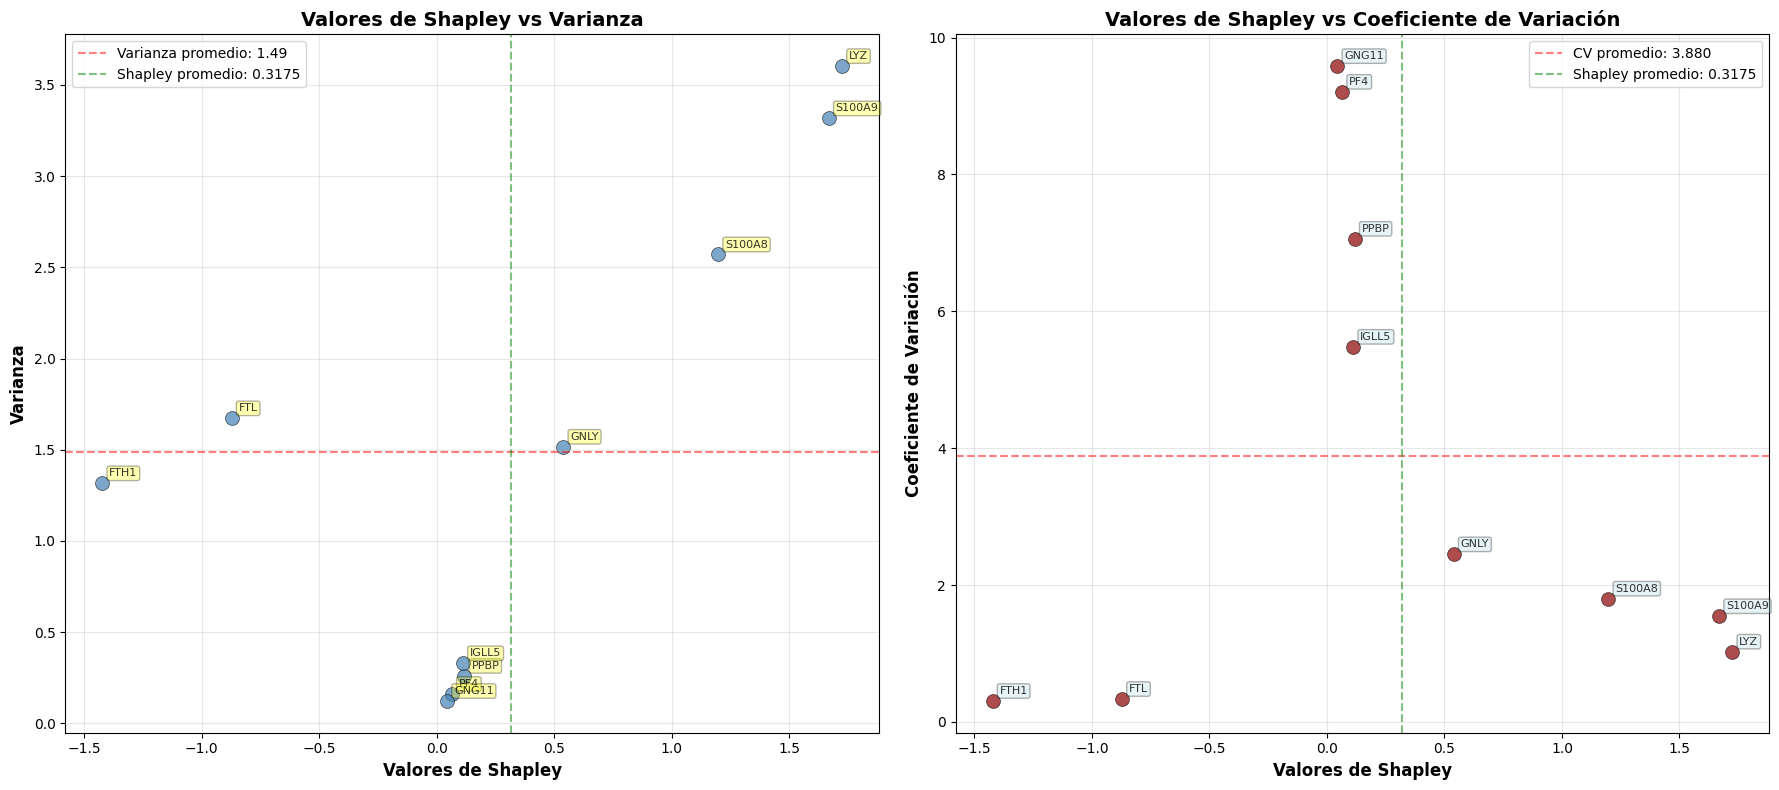

Top 5 genes con mayor valor de Shapley:
      gen  indice  varianza  coeficiente_variacion   shapley
7     LYZ    8681  3.602855               1.027849  1.724741
0  S100A9     907  3.316171               1.545024  1.668494
1  S100A8     909  2.570346               1.802280  1.197669
2    GNLY    1803  1.516380               2.449445  0.539225
4    PPBP    3315  0.260713               7.059455  0.118352

Correlaciones:
Shapley vs Varianza: 0.6391
Shapley vs Coeficiente de Variación: -0.0826
Varianza vs Coeficiente de Variación: -0.7738

Estadísticas de Coeficiente de Variación:
CV promedio: 3.8797
CV máximo: 9.5826
CV mínimo: 0.3067

Análisis combinado guardado en: analisis_shapley_varianza.csv


In [7]:
# Crear scatter plot: Valores de Shapley vs Varianzas y Coeficientes de Variación
print("=== GRÁFICO: VALORES DE SHAPLEY VS VARIANZAS Y CV (DATOS NORMALIZADOS) ===\n")

# Preparar los datos para el gráfico
valores_shapley = []
varianzas_plot = []
nombres_plot = []
coeficientes_variacion = []

# Extraer valores de Shapley ordenados según los índices
for indice in indices_genes_mas_variables:
    valores_shapley.append(y[indice])

# Obtener varianzas en el mismo orden
varianzas_plot = varianzas_genes
nombres_plot = nombres_genes_mas_variables

# Calcular coeficientes de variación para cada gen individual (usando datos normalizados)
for i, indice in enumerate(indices_genes_mas_variables):
    expresion_gen = matriz_norm[indice, :]  # Datos normalizados
    media_gen = np.mean(expresion_gen)
    varianza_gen = varianzas_plot[i]
    cv_gen = np.sqrt(varianza_gen) / media_gen if media_gen > 0 else 0
    coeficientes_variacion.append(cv_gen)

# Crear subplots para mostrar múltiples relaciones
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Subplot 1: Shapley vs Varianza
scatter1 = axes[0].scatter(valores_shapley, varianzas_plot, alpha=0.7, s=100, c='steelblue', edgecolors='black', linewidth=0.5)

# Añadir etiquetas con nombres de genes en el primer subplot
for i, nombre in enumerate(nombres_plot):
    axes[0].annotate(nombre, 
                (valores_shapley[i], varianzas_plot[i]), 
                xytext=(5, 5), 
                textcoords='offset points', 
                fontsize=8, 
                alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.3))

axes[0].set_xlabel('Valores de Shapley', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Varianza', fontsize=12, fontweight='bold')
axes[0].set_title('Valores de Shapley vs Varianza', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Líneas de referencia para el primer subplot
axes[0].axhline(y=np.mean(varianzas_plot), color='red', linestyle='--', alpha=0.5, label=f'Varianza promedio: {np.mean(varianzas_plot):.2f}')
axes[0].axvline(x=np.mean(valores_shapley), color='green', linestyle='--', alpha=0.5, label=f'Shapley promedio: {np.mean(valores_shapley):.4f}')
axes[0].legend()

# Subplot 2: Shapley vs Coeficiente de Variación
scatter2 = axes[1].scatter(valores_shapley, coeficientes_variacion, alpha=0.7, s=100, c='darkred', edgecolors='black', linewidth=0.5)

# Añadir etiquetas con nombres de genes en el segundo subplot
for i, nombre in enumerate(nombres_plot):
    axes[1].annotate(nombre, 
                (valores_shapley[i], coeficientes_variacion[i]), 
                xytext=(5, 5), 
                textcoords='offset points', 
                fontsize=8, 
                alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.3))

axes[1].set_xlabel('Valores de Shapley', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coeficiente de Variación', fontsize=12, fontweight='bold')
axes[1].set_title('Valores de Shapley vs Coeficiente de Variación', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Líneas de referencia para el segundo subplot
axes[1].axhline(y=np.mean(coeficientes_variacion), color='red', linestyle='--', alpha=0.5, label=f'CV promedio: {np.mean(coeficientes_variacion):.3f}')
axes[1].axvline(x=np.mean(valores_shapley), color='green', linestyle='--', alpha=0.5, label=f'Shapley promedio: {np.mean(valores_shapley):.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Crear DataFrame combinado para análisis
df_analisis = pd.DataFrame({
    'gen': nombres_plot,
    'indice': indices_genes_mas_variables,
    'varianza': varianzas_plot,
    'coeficiente_variacion': coeficientes_variacion,
    'shapley': valores_shapley
})

# Ordenar por valor de Shapley
df_analisis_ordenado = df_analisis.sort_values('shapley', ascending=False)

print("Top 5 genes con mayor valor de Shapley:")
print(df_analisis_ordenado.head())

print(f"\nCorrelaciones:")
print(f"Shapley vs Varianza: {np.corrcoef(valores_shapley, varianzas_plot)[0,1]:.4f}")
print(f"Shapley vs Coeficiente de Variación: {np.corrcoef(valores_shapley, coeficientes_variacion)[0,1]:.4f}")
print(f"Varianza vs Coeficiente de Variación: {np.corrcoef(varianzas_plot, coeficientes_variacion)[0,1]:.4f}")

print(f"\nEstadísticas de Coeficiente de Variación:")
print(f"CV promedio: {np.mean(coeficientes_variacion):.4f}")
print(f"CV máximo: {np.max(coeficientes_variacion):.4f}")
print(f"CV mínimo: {np.min(coeficientes_variacion):.4f}")

# Guardar el análisis combinado
df_analisis_ordenado.to_csv("/Users/jose/Desktop/GameTheory_project/analisis_shapley_varianza.csv", index=False)
print(f"\nAnálisis combinado guardado en: analisis_shapley_varianza.csv")

=== VIOLIN PLOT: DISTRIBUCIÓN DE EXPRESIÓN DE GENES (DATOS NORMALIZADOS) ===



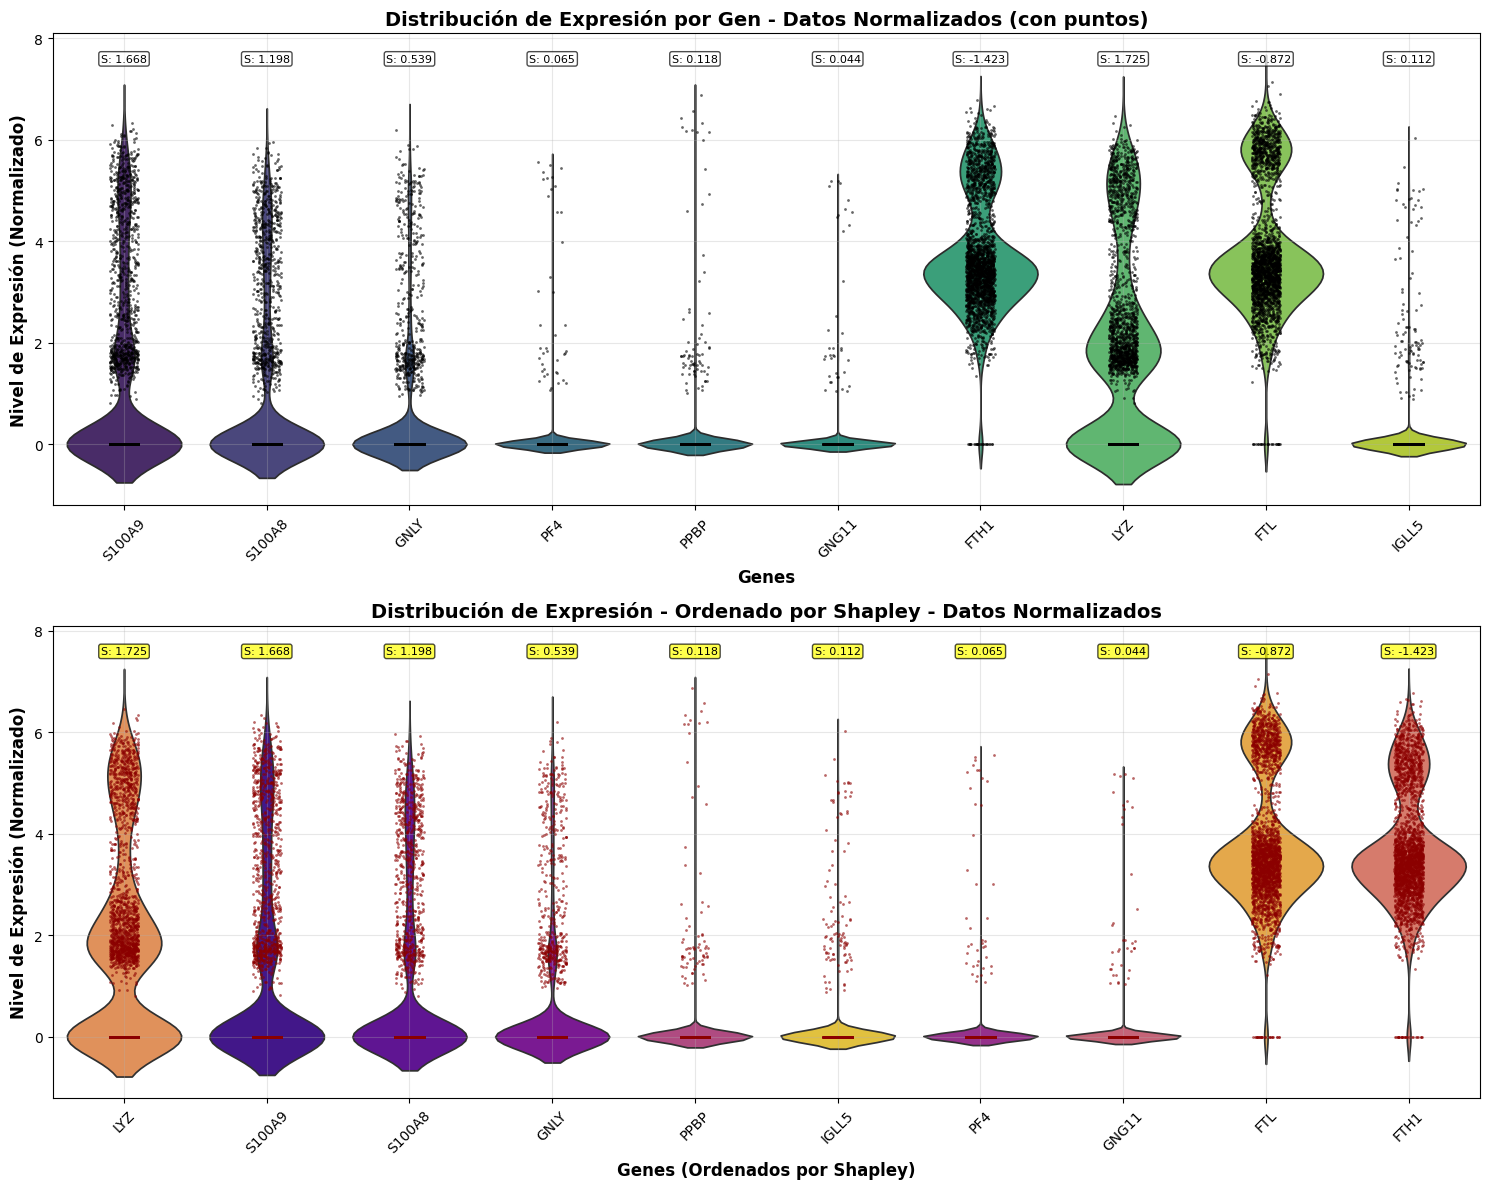


Estadísticas de distribución por gen:
          mean     std  median  min     max
gen                                        
FTH1    3.7400  1.1474  3.4836  0.0  6.7783
FTL     3.8493  1.2935  3.5048  0.0  7.1358
GNG11   0.0366  0.3507  0.0000  0.0  5.1793
GNLY    0.5027  1.2316  0.0000  0.0  6.1924
IGLL5   0.1048  0.5743  0.0000  0.0  6.0229
LYZ     1.8467  1.8985  1.6718  0.0  6.4606
PF4     0.0437  0.4021  0.0000  0.0  5.5560
PPBP    0.0723  0.5107  0.0000  0.0  6.8760
S100A8  0.8896  1.6035  0.0000  0.0  5.9533
S100A9  1.1786  1.8214  0.0000  0.0  6.3319

Comparación con métricas calculadas:
      gen  shapley  varianza  coeficiente_variacion
7     LYZ   1.7247    3.6029                 1.0278
0  S100A9   1.6685    3.3162                 1.5450
1  S100A8   1.1977    2.5703                 1.8023
2    GNLY   0.5392    1.5164                 2.4494
4    PPBP   0.1184    0.2607                 7.0595
9   IGLL5   0.1120    0.3297                 5.4812
3     PF4   0.0647    0.1616   

In [8]:
# Crear violin plot de la expresión de genes más variables
import seaborn as sns

print("=== VIOLIN PLOT: DISTRIBUCIÓN DE EXPRESIÓN DE GENES (DATOS NORMALIZADOS) ===\n")

# Preparar datos para el violin plot
# Crear un DataFrame en formato largo para seaborn
data_violin = []

for i, gen_idx in enumerate(indices_genes_mas_variables):
    gen_nombre = nombres_genes_mas_variables[i]
    expresion_valores = matriz_norm[gen_idx, :]  # Datos normalizados
    
    for valor_expr in expresion_valores:
        data_violin.append({
            'gen': gen_nombre,
            'expresion': valor_expr,
            'shapley': valores_shapley[i],
            'varianza': varianzas_plot[i],
            'cv': coeficientes_variacion[i]
        })

df_violin = pd.DataFrame(data_violin)

# Crear figura con subplots
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Violin plot 1: Distribución de expresión por gen
sns.violinplot(data=df_violin, x='gen', y='expresion', hue='gen', ax=axes[0], palette='viridis', inner=None, legend=False)
# Añadir strip plot con puntos individuales
sns.stripplot(data=df_violin, x='gen', y='expresion', ax=axes[0], 
              size=2, alpha=0.6, color='black', jitter=True)
axes[0].set_title('Distribución de Expresión por Gen - Datos Normalizados (con puntos)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Genes', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nivel de Expresión (Normalizado)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Añadir valores de Shapley como anotaciones en el primer gráfico
for i, gen in enumerate(nombres_genes_mas_variables):
    axes[0].text(i, axes[0].get_ylim()[1] * 0.95, f'S: {valores_shapley[i]:.3f}', 
                ha='center', va='top', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Violin plot 2: Genes ordenados por valor de Shapley
df_violin_ordenado = df_violin.copy()
# Ordenar genes por valor de Shapley
orden_shapley = df_analisis_ordenado['gen'].tolist()
sns.violinplot(data=df_violin_ordenado, x='gen', y='expresion', hue='gen',
               order=orden_shapley, ax=axes[1], palette='plasma', inner=None, legend=False)
# Añadir strip plot con puntos individuales
sns.stripplot(data=df_violin_ordenado, x='gen', y='expresion', 
              order=orden_shapley, ax=axes[1], 
              size=2, alpha=0.6, color='darkred', jitter=True)
axes[1].set_title('Distribución de Expresión - Ordenado por Shapley - Datos Normalizados', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Genes (Ordenados por Shapley)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Nivel de Expresión (Normalizado)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# Añadir valores de Shapley ordenados en el segundo gráfico
for i, gen in enumerate(orden_shapley):
    shapley_val = df_analisis_ordenado[df_analisis_ordenado['gen'] == gen]['shapley'].iloc[0]
    axes[1].text(i, axes[1].get_ylim()[1] * 0.95, f'S: {shapley_val:.3f}', 
                ha='center', va='top', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# Estadísticas de distribución por gen
print("\nEstadísticas de distribución por gen:")
stats_genes = df_violin.groupby('gen')['expresion'].agg(['mean', 'std', 'median', 'min', 'max']).round(4)
print(stats_genes)

# Comparar con valores de Shapley
print(f"\nComparación con métricas calculadas:")
comparison = df_analisis_ordenado[['gen', 'shapley', 'varianza', 'coeficiente_variacion']].round(4)
print(comparison)

=== ANÁLISIS INTEGRAL: CV, SHAPLEY Y MEDIA DE EXPRESIÓN (DATOS NORMALIZADOS) ===



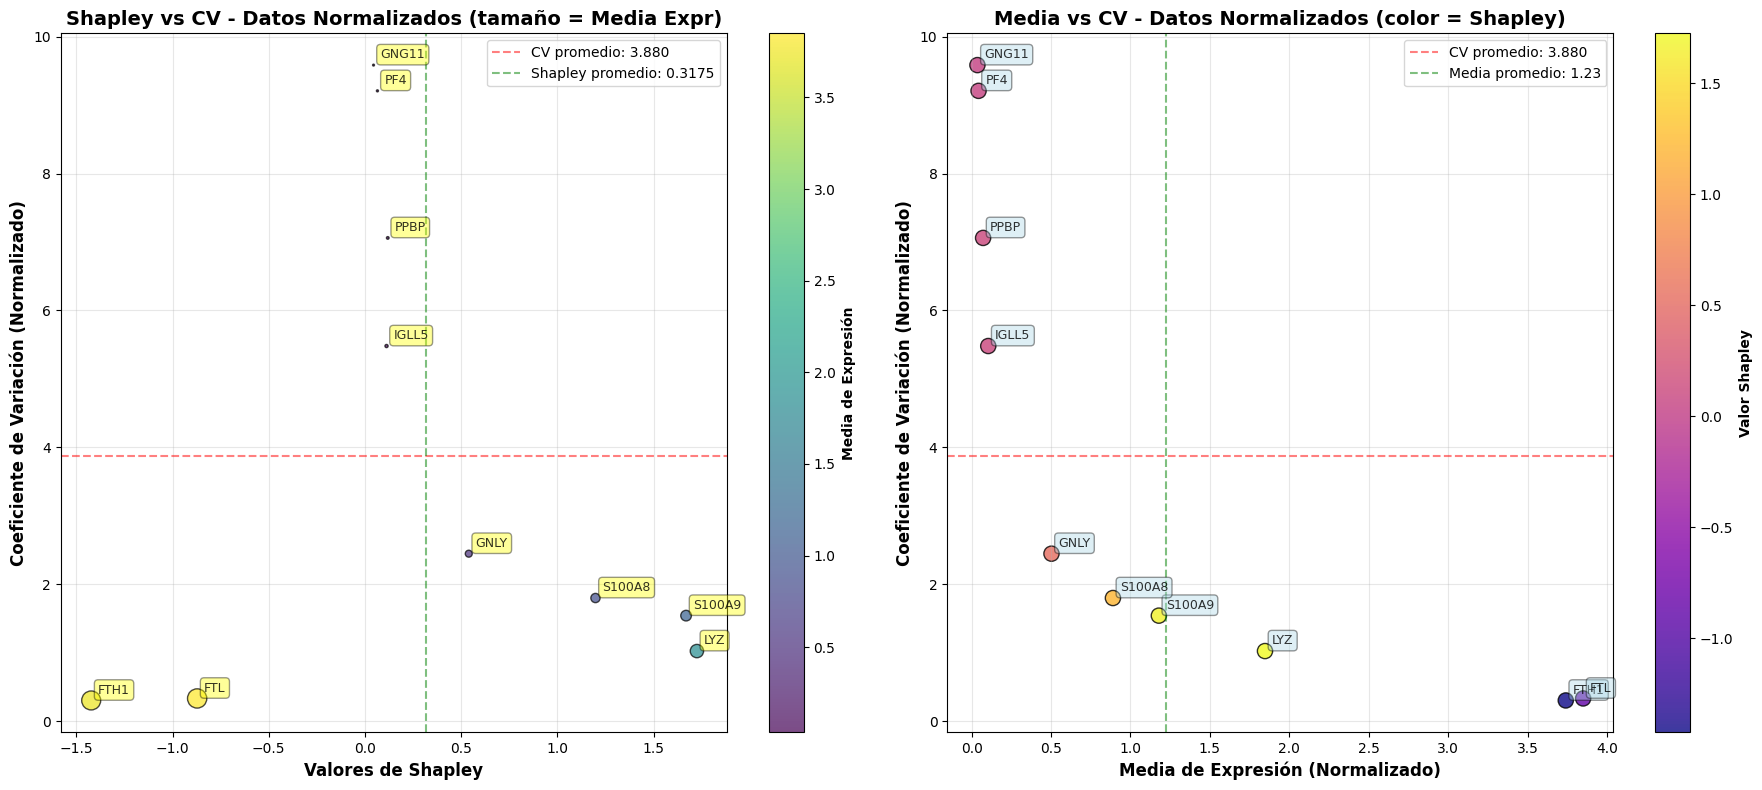


Correlaciones entre métricas:
Shapley vs CV: -0.0826
Shapley vs Media: -0.4486
Media vs CV: -0.7609

Tabla resumen de métricas principales:
      gen  shapley  coeficiente_variacion  media_expresion
0  S100A9   1.6685                 1.5450           1.1786
1  S100A8   1.1977                 1.8023           0.8896
2    GNLY   0.5392                 2.4494           0.5027
3     PF4   0.0647                 9.2066           0.0437
4    PPBP   0.1184                 7.0595           0.0723
5   GNG11   0.0444                 9.5826           0.0366
6    FTH1  -1.4227                 0.3067           3.7400
7     LYZ   1.7247                 1.0278           1.8467
8     FTL  -0.8721                 0.3360           3.8493
9   IGLL5   0.1120                 5.4812           0.1048

Análisis completo guardado en: analisis_completo_genes.csv


In [9]:
# Visualización integral: CV, Shapley y Media de Expresión
print("=== ANÁLISIS INTEGRAL: CV, SHAPLEY Y MEDIA DE EXPRESIÓN (DATOS NORMALIZADOS) ===\n")

# Calcular medias de expresión para cada gen (usando datos normalizados)
medias_expresion = []
for indice in indices_genes_mas_variables:
    media_expr = np.mean(matriz_norm[indice, :])  # Datos normalizados
    medias_expresion.append(media_expr)

# Crear DataFrame completo con todas las métricas
df_completo = pd.DataFrame({
    'gen': nombres_genes_mas_variables,
    'indice': indices_genes_mas_variables,
    'media_expresion': medias_expresion,
    'coeficiente_variacion': coeficientes_variacion,
    'shapley': valores_shapley,
    'varianza': varianzas_plot
})

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Scatter plot con tamaño proporcional a media de expresión
scatter1 = axes[0].scatter(df_completo['shapley'], df_completo['coeficiente_variacion'], 
                          s=df_completo['media_expresion']*50, # tamaño proporcional a media
                          c=df_completo['media_expresion'], cmap='viridis', 
                          alpha=0.7, edgecolors='black', linewidth=1)

# Añadir etiquetas al plot 1
for i, nombre in enumerate(df_completo['gen']):
    axes[0].annotate(nombre, (df_completo['shapley'].iloc[i], df_completo['coeficiente_variacion'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.4))

axes[0].set_xlabel('Valores de Shapley', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Coeficiente de Variación (Normalizado)', fontsize=12, fontweight='bold')
axes[0].set_title('Shapley vs CV - Datos Normalizados (tamaño = Media Expr)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Añadir líneas de referencia al plot 1
axes[0].axhline(y=np.mean(df_completo['coeficiente_variacion']), color='red', linestyle='--', alpha=0.5, 
               label=f'CV promedio: {np.mean(df_completo["coeficiente_variacion"]):.3f}')
axes[0].axvline(x=np.mean(df_completo['shapley']), color='green', linestyle='--', alpha=0.5, 
               label=f'Shapley promedio: {np.mean(df_completo["shapley"]):.4f}')
axes[0].legend()

# Colorbar para plot 1
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Media de Expresión', fontweight='bold')

# Plot 4: Media vs CV, coloreado por Shapley
scatter2 = axes[1].scatter(df_completo['media_expresion'], df_completo['coeficiente_variacion'],
                          c=df_completo['shapley'], cmap='plasma', s=120, 
                          alpha=0.8, edgecolors='black', linewidth=1)

# Añadir etiquetas al plot 4
for i, nombre in enumerate(df_completo['gen']):
    axes[1].annotate(nombre, (df_completo['media_expresion'].iloc[i], df_completo['coeficiente_variacion'].iloc[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.4))

axes[1].set_xlabel('Media de Expresión (Normalizado)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Coeficiente de Variación (Normalizado)', fontsize=12, fontweight='bold')
axes[1].set_title('Media vs CV - Datos Normalizados (color = Shapley)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Añadir líneas de referencia al plot 4
axes[1].axhline(y=np.mean(df_completo['coeficiente_variacion']), color='red', linestyle='--', alpha=0.5,
               label=f'CV promedio: {np.mean(df_completo["coeficiente_variacion"]):.3f}')
axes[1].axvline(x=np.mean(df_completo['media_expresion']), color='green', linestyle='--', alpha=0.5,
               label=f'Media promedio: {np.mean(df_completo["media_expresion"]):.2f}')
axes[1].legend()

# Colorbar para plot 4
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Valor Shapley', fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir correlaciones relevantes
print("\nCorrelaciones entre métricas:")
print(f"Shapley vs CV: {np.corrcoef(df_completo['shapley'], df_completo['coeficiente_variacion'])[0,1]:.4f}")
print(f"Shapley vs Media: {np.corrcoef(df_completo['shapley'], df_completo['media_expresion'])[0,1]:.4f}")
print(f"Media vs CV: {np.corrcoef(df_completo['media_expresion'], df_completo['coeficiente_variacion'])[0,1]:.4f}")

# Imprimir tabla resumen
print("\nTabla resumen de métricas principales:")
df_resumen = df_completo[['gen', 'shapley', 'coeficiente_variacion', 'media_expresion']].round(4)
print(df_resumen)

# Guardar datos completos
df_completo.to_csv("/Users/jose/Desktop/GameTheory_project/analisis_completo_genes.csv", index=False)
print(f"\nAnálisis completo guardado en: analisis_completo_genes.csv")

REPORTE DE ANÁLISIS DE TEORÍA DE JUEGOS EN DATOS scRNA-seq (DATOS NORMALIZADOS)
Fecha de generación: 2025-10-09 11:03:42
Número de genes analizados: 10
Número de células: 2638
NOTA: Análisis realizado con datos normalizados (target_sum=1e4) y log-transformados

🎻 FIGURA 1: DISTRIBUCIÓN DE EXPRESIÓN GÉNICA (DATOS NORMALIZADOS)
------------------------------------------------------------

📈 FIGURA 2: SHAPLEY vs VARIANZAS Y COEFICIENTES DE VARIACIÓN
----------------------------------------------------------------------

📊 FIGURA 3: ANÁLISIS MULTIDIMENSIONAL CON MEDIA DE EXPRESIÓN
----------------------------------------------------------------------


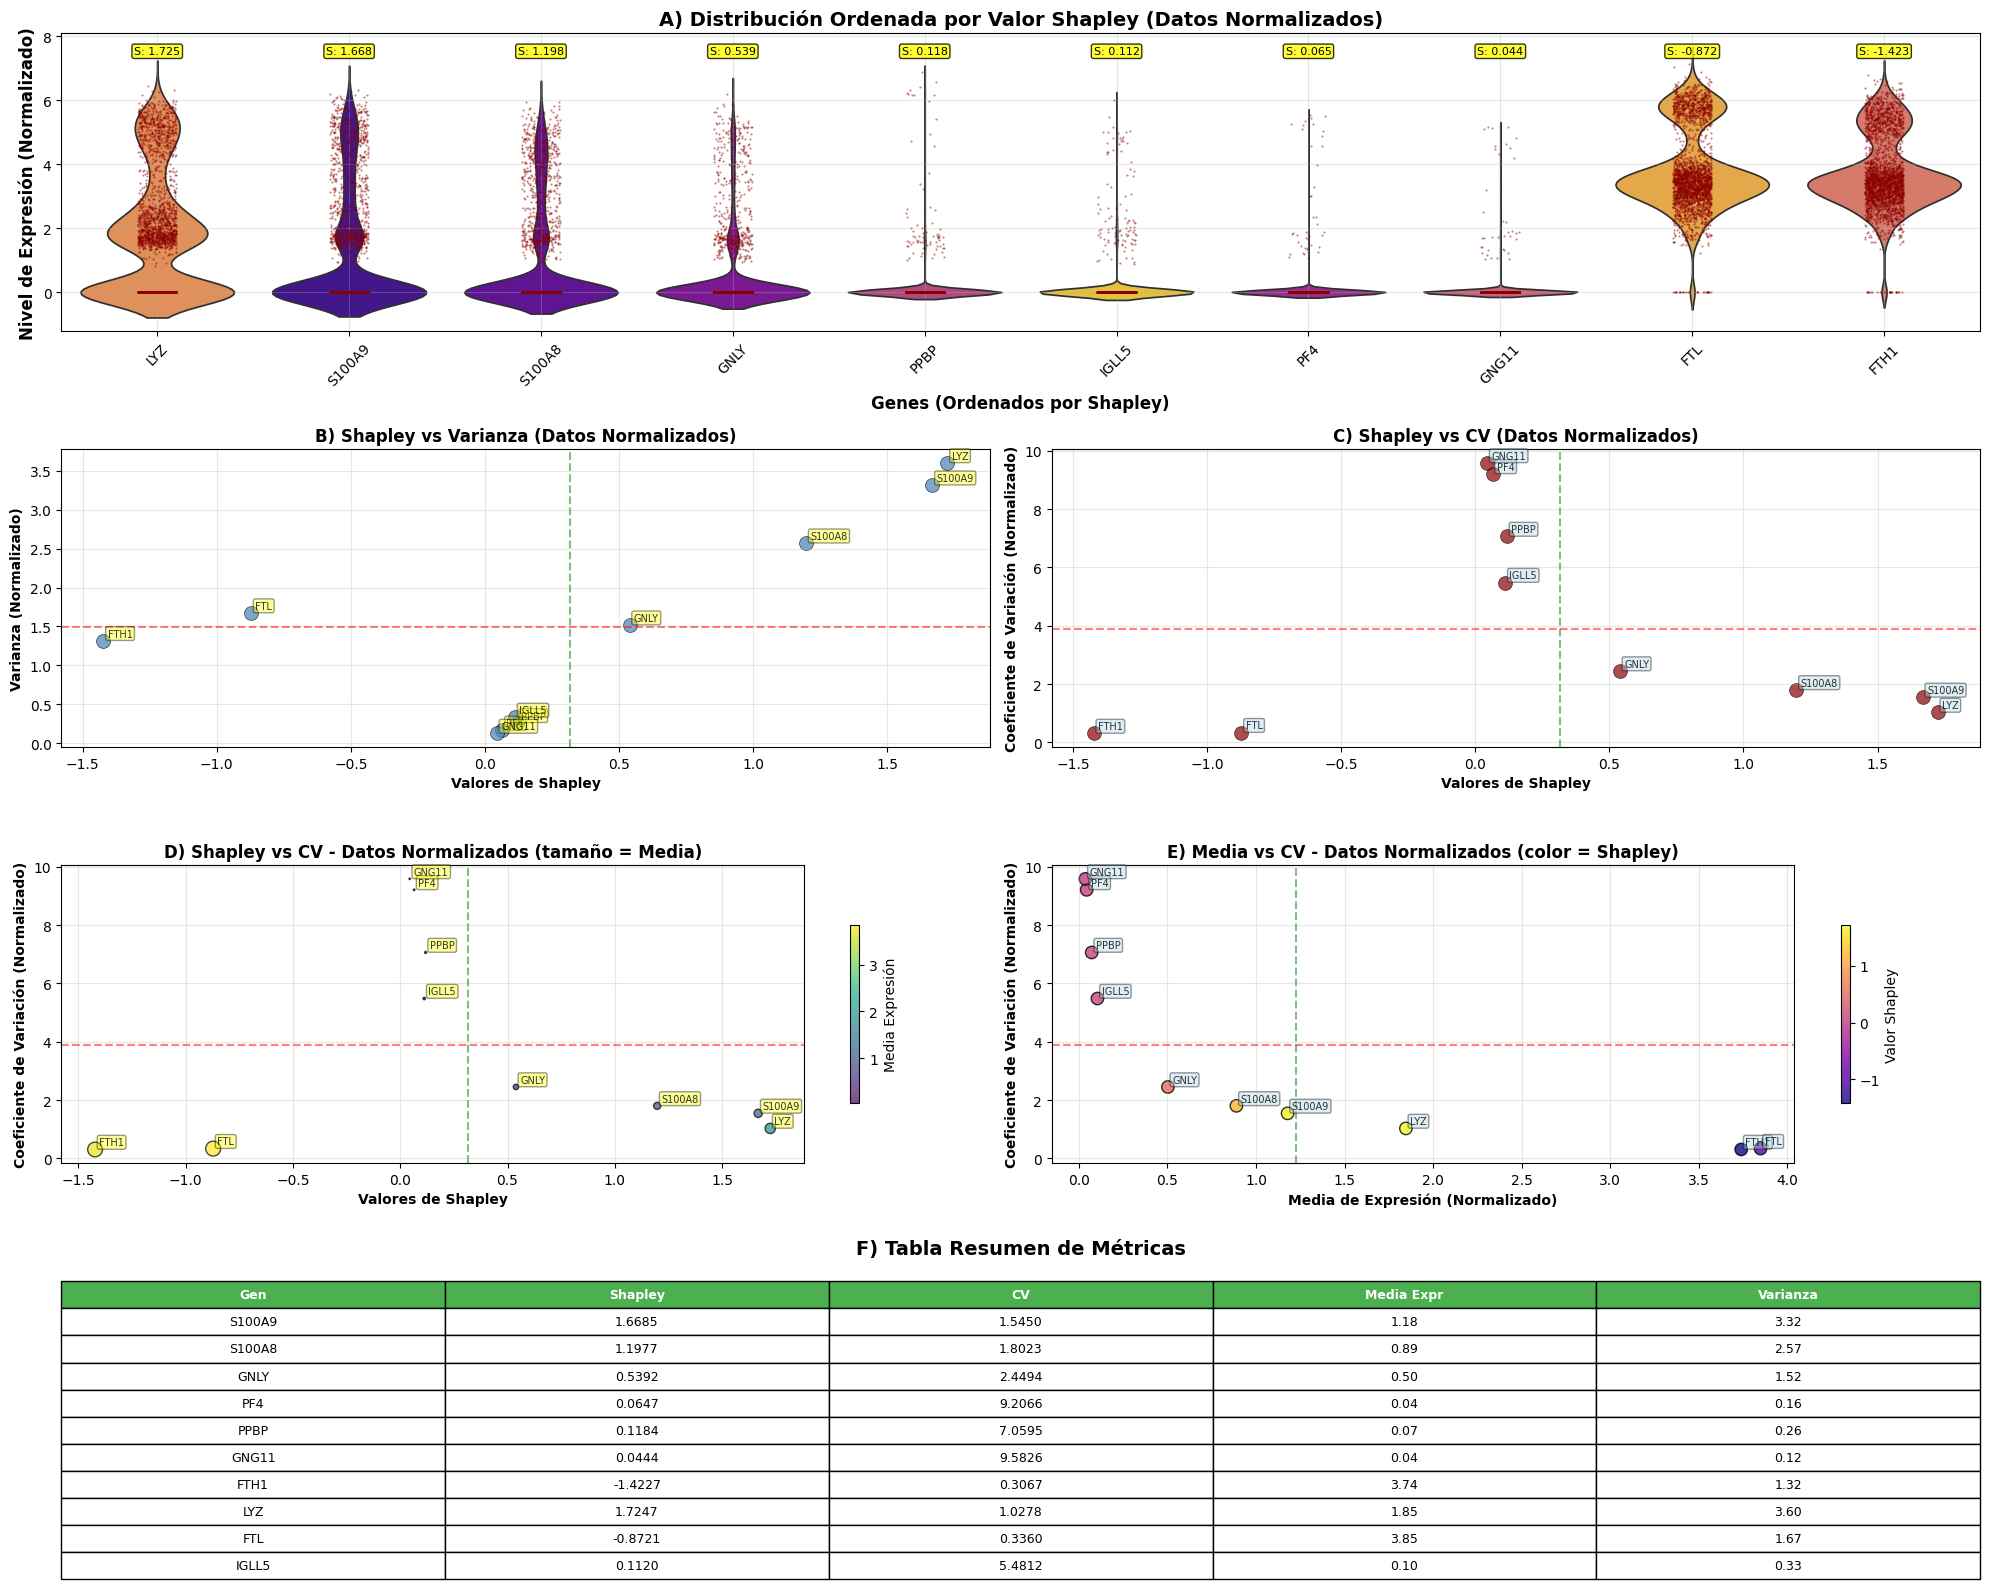


📈 ANÁLISIS ESTADÍSTICO DETALLADO

🔍 ESTADÍSTICAS DESCRIPTIVAS:
Métrica              Media      Std        Min        Max       
------------------------------------------------------------
Shapley              0.3175     0.9640     -1.4227    1.7247    
CV                   3.8797     3.4474     0.3067     9.5826    
Media Expresión      1.23       1.40       0.04       3.85      
Varianza             1.49       1.25       0.12       3.60      

🔗 MATRIZ DE CORRELACIONES:
                       shapley  coeficiente_variacion  media_expresion  \
shapley                 1.0000                -0.0826          -0.4486   
coeficiente_variacion  -0.0826                 1.0000          -0.7609   
media_expresion        -0.4486                -0.7609           1.0000   
varianza                0.6391                -0.7738           0.3896   

                       varianza  
shapley                  0.6391  
coeficiente_variacion   -0.7738  
media_expresion          0.3896  
varianza       

<Figure size 640x480 with 0 Axes>

In [10]:
# REPORTE FINAL: Análisis de Teoría de Juegos en scRNA-seq
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("REPORTE DE ANÁLISIS DE TEORÍA DE JUEGOS EN DATOS scRNA-seq (DATOS NORMALIZADOS)")
print("="*80)
print(f"Fecha de generación: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Número de genes analizados: {len(nombres_genes_mas_variables)}")
print(f"Número de células: {num_columnas}")
print("NOTA: Análisis realizado con datos normalizados (target_sum=1e4) y log-transformados")
print("="*80)

# Regenerar las figuras principales para el reporte
fig_reporte = plt.figure(figsize=(20, 16))

# FIGURA 1: VIOLIN PLOT (recrear de la celda 8)
print("\n🎻 FIGURA 1: DISTRIBUCIÓN DE EXPRESIÓN GÉNICA (DATOS NORMALIZADOS)")
print("-" * 60)

# Subplot 1: Violin plot ordenado por Shapley
ax1 = plt.subplot(4, 2, (1, 2))
orden_shapley = df_analisis_ordenado['gen'].tolist()
sns.violinplot(data=df_violin_ordenado, x='gen', y='expresion', hue='gen',
               order=orden_shapley, ax=ax1, palette='plasma', inner=None, legend=False)
sns.stripplot(data=df_violin_ordenado, x='gen', y='expresion', 
              order=orden_shapley, ax=ax1, size=1.5, alpha=0.5, color='darkred', jitter=True)

# Añadir valores de Shapley ordenados
for i, gen in enumerate(orden_shapley):
    shapley_val = df_analisis_ordenado[df_analisis_ordenado['gen'] == gen]['shapley'].iloc[0]
    ax1.text(i, ax1.get_ylim()[1] * 0.95, f'S: {shapley_val:.3f}', 
            ha='center', va='top', fontsize=8, 
            bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))

ax1.set_title('A) Distribución Ordenada por Valor Shapley (Datos Normalizados)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Genes (Ordenados por Shapley)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Nivel de Expresión (Normalizado)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# FIGURA 2: SCATTER PLOTS SHAPLEY vs VARIANZAS/CV (de la celda 7)
print("\n📈 FIGURA 2: SHAPLEY vs VARIANZAS Y COEFICIENTES DE VARIACIÓN")
print("-" * 70)

# Subplot 2.1: Shapley vs Varianza
ax2 = plt.subplot(4, 2, 3)
scatter2 = ax2.scatter(valores_shapley, varianzas_plot, alpha=0.7, s=100, c='steelblue', edgecolors='black', linewidth=0.5)

for i, nombre in enumerate(nombres_plot):
    ax2.annotate(nombre, (valores_shapley[i], varianzas_plot[i]), 
                xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.4))

ax2.set_xlabel('Valores de Shapley', fontweight='bold')
ax2.set_ylabel('Varianza (Normalizado)', fontweight='bold')
ax2.set_title('B) Shapley vs Varianza (Datos Normalizados)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=np.mean(varianzas_plot), color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=np.mean(valores_shapley), color='green', linestyle='--', alpha=0.5)

# Subplot 2.2: Shapley vs Coeficiente de Variación
ax3 = plt.subplot(4, 2, 4)
scatter3 = ax3.scatter(valores_shapley, coeficientes_variacion, alpha=0.7, s=100, c='darkred', edgecolors='black', linewidth=0.5)

for i, nombre in enumerate(nombres_plot):
    ax3.annotate(nombre, (valores_shapley[i], coeficientes_variacion[i]), 
                xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.4))

ax3.set_xlabel('Valores de Shapley', fontweight='bold')
ax3.set_ylabel('Coeficiente de Variación (Normalizado)', fontweight='bold')
ax3.set_title('C) Shapley vs CV (Datos Normalizados)', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=np.mean(coeficientes_variacion), color='red', linestyle='--', alpha=0.5)
ax3.axvline(x=np.mean(valores_shapley), color='green', linestyle='--', alpha=0.5)

# FIGURA 3: ANÁLISIS MULTIDIMENSIONAL (de la celda 9)
print("\n📊 FIGURA 3: ANÁLISIS MULTIDIMENSIONAL CON MEDIA DE EXPRESIÓN")
print("-" * 70)

# Subplot 3.1: Shapley vs CV con tamaño = media
ax4 = plt.subplot(4, 2, 5)
scatter4 = ax4.scatter(df_completo['shapley'], df_completo['coeficiente_variacion'], 
                      s=df_completo['media_expresion']*30, c=df_completo['media_expresion'], 
                      cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1)

for i, nombre in enumerate(df_completo['gen']):
    ax4.annotate(nombre, (df_completo['shapley'].iloc[i], df_completo['coeficiente_variacion'].iloc[i]),
                xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.4))

ax4.set_xlabel('Valores de Shapley', fontweight='bold')
ax4.set_ylabel('Coeficiente de Variación (Normalizado)', fontweight='bold')
ax4.set_title('D) Shapley vs CV - Datos Normalizados (tamaño = Media)', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axhline(y=np.mean(df_completo['coeficiente_variacion']), color='red', linestyle='--', alpha=0.5)
ax4.axvline(x=np.mean(df_completo['shapley']), color='green', linestyle='--', alpha=0.5)

# Subplot 3.2: Media vs CV coloreado por Shapley
ax5 = plt.subplot(4, 2, 6)
scatter5 = ax5.scatter(df_completo['media_expresion'], df_completo['coeficiente_variacion'],
                      c=df_completo['shapley'], cmap='plasma', s=80, 
                      alpha=0.8, edgecolors='black', linewidth=1)

for i, nombre in enumerate(df_completo['gen']):
    ax5.annotate(nombre, (df_completo['media_expresion'].iloc[i], df_completo['coeficiente_variacion'].iloc[i]),
                xytext=(3, 3), textcoords='offset points', fontsize=7, alpha=0.8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.4))

ax5.set_xlabel('Media de Expresión (Normalizado)', fontweight='bold')
ax5.set_ylabel('Coeficiente de Variación (Normalizado)', fontweight='bold')
ax5.set_title('E) Media vs CV - Datos Normalizados (color = Shapley)', fontweight='bold')
ax5.grid(True, alpha=0.3)
ax5.axhline(y=np.mean(df_completo['coeficiente_variacion']), color='red', linestyle='--', alpha=0.5)
ax5.axvline(x=np.mean(df_completo['media_expresion']), color='green', linestyle='--', alpha=0.5)

# Colorbars
plt.colorbar(scatter4, ax=ax4, label='Media Expresión', shrink=0.6)
plt.colorbar(scatter5, ax=ax5, label='Valor Shapley', shrink=0.6)

# TABLA RESUMEN
ax6 = plt.subplot(4, 2, (7, 8))
ax6.axis('tight')
ax6.axis('off')

# Crear tabla resumen
tabla_datos = []
for _, row in df_completo.iterrows():
    tabla_datos.append([
        row['gen'],
        f"{row['shapley']:.4f}",
        f"{row['coeficiente_variacion']:.4f}",
        f"{row['media_expresion']:.2f}",
        f"{row['varianza']:.2f}"
    ])

tabla = ax6.table(cellText=tabla_datos,
                 colLabels=['Gen', 'Shapley', 'CV', 'Media Expr', 'Varianza'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 1.5)

# Colorear header
for i in range(5):
    tabla[(0, i)].set_facecolor('#4CAF50')
    tabla[(0, i)].set_text_props(weight='bold', color='white')

ax6.set_title('F) Tabla Resumen de Métricas', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ANÁLISIS ESTADÍSTICO DETALLADO
print("\n📈 ANÁLISIS ESTADÍSTICO DETALLADO")
print("="*60)

print(f"\n🔍 ESTADÍSTICAS DESCRIPTIVAS:")
print(f"{'Métrica':<20} {'Media':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
print("-"*60)
print(f"{'Shapley':<20} {np.mean(df_completo['shapley']):<10.4f} {np.std(df_completo['shapley']):<10.4f} {np.min(df_completo['shapley']):<10.4f} {np.max(df_completo['shapley']):<10.4f}")
print(f"{'CV':<20} {np.mean(df_completo['coeficiente_variacion']):<10.4f} {np.std(df_completo['coeficiente_variacion']):<10.4f} {np.min(df_completo['coeficiente_variacion']):<10.4f} {np.max(df_completo['coeficiente_variacion']):<10.4f}")
print(f"{'Media Expresión':<20} {np.mean(df_completo['media_expresion']):<10.2f} {np.std(df_completo['media_expresion']):<10.2f} {np.min(df_completo['media_expresion']):<10.2f} {np.max(df_completo['media_expresion']):<10.2f}")
print(f"{'Varianza':<20} {np.mean(df_completo['varianza']):<10.2f} {np.std(df_completo['varianza']):<10.2f} {np.min(df_completo['varianza']):<10.2f} {np.max(df_completo['varianza']):<10.2f}")

print(f"\n🔗 MATRIZ DE CORRELACIONES:")
corr_matrix = df_completo[['shapley', 'coeficiente_variacion', 'media_expresion', 'varianza']].corr()
print(corr_matrix.round(4))

print(f"\n🏆 TOP 3 GENES POR VALOR SHAPLEY:")
top_genes = df_completo.nlargest(3, 'shapley')
for i, (_, row) in enumerate(top_genes.iterrows(), 1):
    print(f"{i}. {row['gen']:>8}: Shapley={row['shapley']:.4f}, CV={row['coeficiente_variacion']:.4f}, Media={row['media_expresion']:.2f}")

print(f"\n📊 INTERPRETACIÓN (ESTRATEGIA HÍBRIDA):")
print("- Los valores de Shapley se calculan usando datos RAW que se normalizan DESPUÉS de sumar")
print("- Las métricas individuales (CV, varianza, media) usan datos ya normalizados")
print("- Esta estrategia combina lo mejor de ambos enfoques:")
print("  * Shapley: Refleja la contribución real de cada gen en la suma normalizada")
print("  * Métricas individuales: Permiten comparaciones equitativas entre genes")
print("- La combinación identifica genes clave para caracterizar poblaciones celulares")

# Guardar reporte en PDF y PNG
fecha_str = datetime.now().strftime('%Y%m%d_%H%M%S')
reporte_pdf_path = f"/Users/jose/Desktop/GameTheory_project/reporte_gametheory_{fecha_str}.pdf"
reporte_png_path = f"/Users/jose/Desktop/GameTheory_project/reporte_gametheory_{fecha_str}.png"

# Asegurar que la figura esté completa antes de guardar
plt.tight_layout(pad=2.0)

# Guardar en PDF con alta calidad usando la figura actual
fig_reporte.savefig(reporte_pdf_path, format='pdf', dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')

# Guardar también en PNG como respaldo
fig_reporte.savefig(reporte_png_path, format='png', dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')

print(f"\n💾 ARCHIVOS GENERADOS:")
print(f"- Reporte PDF: reporte_gametheory_{fecha_str}.pdf")
print(f"- Reporte PNG: reporte_gametheory_{fecha_str}.png")
print("- Datos completos: analisis_completo_genes.csv")
print("- Análisis Shapley-Varianza: analisis_shapley_varianza.csv")
print("- Varianzas individuales: varianzas_genes_variables.csv")

print("\n✅ REPORTE COMPLETADO")
print("="*80)